# Proyecto Avance 3 - Modelos de clasificación


## 1. Carga de librerías

In [13]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

os.makedirs("outputs", exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

## 2. Carga de datos


In [14]:
def cargar_datos():
    ruta_sav = "base_final_unificada_normalizada.sav"

    if os.path.exists(ruta_sav):
        try:
            df = pd.read_spss(ruta_sav)
            print(f"Base cargada desde: {ruta_sav}")
            return df
        except Exception as e:
            print("No se pudo leer el archivo .sav.")
            print("Detalle:", e)
            print("Probablemente falta instalar pyreadstat. Probá ejecutar:")
            print("pip install pyreadstat")
            print("Se intentará cargar archivos .xlsx como respaldo.\n")

    archivos_xlsx = sorted(glob.glob("divorcios*.xlsx"))
    if len(archivos_xlsx) > 0:
        lista = []
        for archivo in archivos_xlsx:
            temp = pd.read_excel(archivo)

            # Normalizar nombres equivalentes que cambian entre años
            temp = temp.rename(columns={
                "PPERHOM": "PUEHOM",
                "PPERMUJ": "PUEMUJ"
            })

            temp["ARCHIVO_ORIGEN"] = os.path.basename(archivo)
            lista.append(temp)

        df = pd.concat(lista, ignore_index=True)
        print(f"Base cargada desde {len(archivos_xlsx)} archivos xlsx.")
        return df

    raise FileNotFoundError(
        "No se encontró base_final_unificada_normalizada.sav ni archivos divorcios*.xlsx. "
        "Colocá la base en la misma carpeta del notebook."
    )

df = cargar_datos()

print("Dimensiones de la base:", df.shape)
display(df.head())
display(df.dtypes.to_frame("tipo_dato").T)

Base cargada desde: base_final_unificada_normalizada.sav
Dimensiones de la base: (71576, 23)


,DEPREG,MUPREG,MESREG,AÑOREG,DIAOCU,MESOCU,AÑOOCU,DEPOCU,MUPOCU,EDADHOM,EDADMUJ,PUEHOM,PUEMUJ,NACHOM,NACMUJ,ESCHOM,ESCMUJ,CIUOHOM,CIUOMUJ,GETHOM,GETMUJ,OCUHOM,OCUMUJ
0,Guatemala,Guatemala,Diciembre,2016.0000,3.0000,Noviembre,2016.0000,Guatemala,Guatemala,Ignorado,Ignorado,Ignorado,Ignorado,Argentina,Guatemala,Ignorado,Ignorado,No especificado en otro grupo,Profesionales de la enseñanza,,,,
1,Guatemala,Guatemala,Agosto,2016.0000,17.0000,Mayo,2016.0000,Guatemala,Guatemala,58.0,Ignorado,Ignorado,Ignorado,Argentina,Guatemala,Ignorado,Ignorado,No especificado en otro grupo,No especificado en otro grupo,,,,
2,Peten,Flores,Agosto,2016.0000,11.0000,Agosto,2016.0000,Guatemala,Guatemala,61.0,53.0,Ignorado,Ignorado,Argentina,Guatemala,Ninguno,Ninguno,Ignorado,Ignorado,,,,
3,Guatemala,Guatemala,Marzo,2017.0000,7.0000,Octubre,2016.0000,Guatemala,Guatemala,39.0,38.0,Ignorado,Mestizo / Ladino,Austria,Guatemala,Ignorado,Universitario,Vendedores,"Profesionales en derecho, en ciencias sociales...",,,,
4,Zacapa,Teculután,Febrero,2017.0000,23.0000,Noviembre,2016.0000,El Progreso,Sanarate,Ignorado,Ignorado,Ignorado,Ignorado,Chile,Guatemala,Ignorado,Ignorado,"Oficiales y operarios de la metalurgia, la con...",No especificado en otro grupo,,,,


,DEPREG,MUPREG,MESREG,AÑOREG,DIAOCU,MESOCU,AÑOOCU,DEPOCU,MUPOCU,EDADHOM,EDADMUJ,PUEHOM,PUEMUJ,NACHOM,NACMUJ,ESCHOM,ESCMUJ,CIUOHOM,CIUOMUJ,GETHOM,GETMUJ,OCUHOM,OCUMUJ
tipo_dato,str,str,str,float64,float64,str,float64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str


## 3. Limpieza mínima de edades


In [15]:
df_modelo = df.copy()

# Asegurar que las edades sean numéricas
for col in ["EDADHOM", "EDADMUJ"]:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")

# Limpiar códigos o edades no realistas
df_modelo.loc[(df_modelo["EDADHOM"] < 15) | (df_modelo["EDADHOM"] > 100), "EDADHOM"] = np.nan
df_modelo.loc[(df_modelo["EDADMUJ"] < 15) | (df_modelo["EDADMUJ"] > 100), "EDADMUJ"] = np.nan

antes = len(df_modelo)
df_modelo = df_modelo.dropna(subset=["EDADHOM", "EDADMUJ"]).copy()
despues = len(df_modelo)

print(f"Registros antes de limpiar edades: {antes:,}")
print(f"Registros después de limpiar edades: {despues:,}")
print(f"Registros eliminados: {antes - despues:,}")

df_modelo[["EDADHOM", "EDADMUJ"]].describe()

Registros antes de limpiar edades: 71,576
Registros después de limpiar edades: 34,359
Registros eliminados: 37,217


,EDADHOM,EDADMUJ
count,34359.0000,34359.0000
mean,35.4729,32.3101
std,9.7657,8.8623
min,15.0000,15.0000
25%,29.0000,26.0000
50%,33.0000,31.0000
75%,40.0000,37.0000
max,98.0000,81.0000


## 4. Variable respuesta

Puntos de corte usados para la variable respuesta:
Corte 0: 17.00
Corte 1: 29.00
Corte 2: 35.50
Corte 3: 81.50


,frecuencia,porcentaje
ETAPA_VIDA_PAREJA,,
temprana,11819,34.4000
intermedia,11091,32.2800
tardia,11449,33.3200


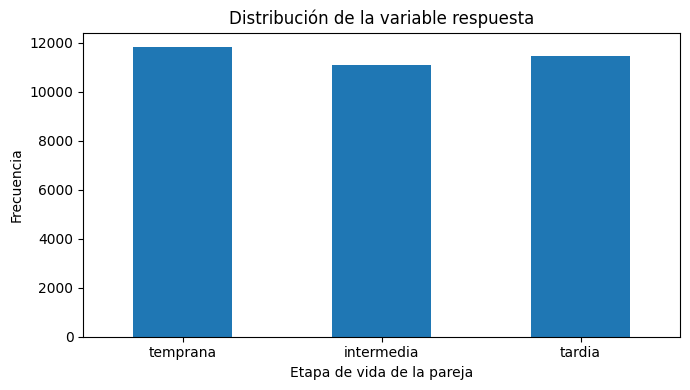

In [16]:
df_modelo["EDAD_PROMEDIO_PAREJA"] = (
    df_modelo["EDADHOM"] + df_modelo["EDADMUJ"]
) / 2

# qcut crea grupos con cantidades similares de observaciones
df_modelo["ETAPA_VIDA_PAREJA"], cortes = pd.qcut(
    df_modelo["EDAD_PROMEDIO_PAREJA"],
    q=3,
    labels=["temprana", "intermedia", "tardia"],
    retbins=True,
    duplicates="drop"
)

print("Puntos de corte usados para la variable respuesta:")
for i, corte in enumerate(cortes):
    print(f"Corte {i}: {corte:.2f}")

tabla_respuesta = (
    df_modelo["ETAPA_VIDA_PAREJA"]
    .value_counts()
    .sort_index()
    .to_frame("frecuencia")
)
tabla_respuesta["porcentaje"] = (tabla_respuesta["frecuencia"] / len(df_modelo) * 100).round(2)

display(tabla_respuesta)

plt.figure(figsize=(7, 4))
tabla_respuesta["frecuencia"].plot(kind="bar")
plt.title("Distribución de la variable respuesta")
plt.xlabel("Etapa de vida de la pareja")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/grafico1_distribucion_variable_respuesta.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Variables predictoras


In [17]:
target = "ETAPA_VIDA_PAREJA"

columnas_no_predictoras = [
    target,
    "EDAD_PROMEDIO_PAREJA",
    "EDADHOM",
    "EDADMUJ"
]

X = df_modelo.drop(columns=[c for c in columnas_no_predictoras if c in df_modelo.columns])
y = df_modelo[target].astype(str)

# Columnas que se tratarán como categóricas aunque vengan codificadas con números
cat_cols_posibles = [
    "DEPREG", "MUPREG", "MESREG",
    "MESOCU", "DEPOCU", "MUPOCU",
    "PUEHOM", "PUEMUJ", "PPERHOM", "PPERMUJ",
    "NACHOM", "NACMUJ",
    "ESCHOM", "ESCMUJ",
    "CIUOHOM", "CIUOMUJ",
    "GETHOM", "GETMUJ",
    "OCUHOM", "OCUMUJ",
    "CLAUNI", "NUNUHO", "NUNUMU",
    "ARCHIVO_ORIGEN"
]

num_cols_posibles = ["DIAOCU", "AÑOOCU", "AÑOREG"]

cat_cols = [c for c in cat_cols_posibles if c in X.columns]
num_cols = [c for c in num_cols_posibles if c in X.columns]

# Cualquier columna restante se decide según su tipo
otras = [c for c in X.columns if c not in cat_cols + num_cols]
for c in otras:
    if pd.api.types.is_numeric_dtype(X[c]):
        num_cols.append(c)
    else:
        cat_cols.append(c)

# Convertir columnas categóricas a object para que OneHotEncoder las trate como categorías
for c in cat_cols:
    X[c] = X[c].astype("object").where(X[c].notna(), np.nan)

print("Cantidad de variables predictoras:", X.shape[1])
print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)

Cantidad de variables predictoras: 21
Columnas numéricas: ['DIAOCU', 'AÑOOCU', 'AÑOREG']
Columnas categóricas: ['DEPREG', 'MUPREG', 'MESREG', 'MESOCU', 'DEPOCU', 'MUPOCU', 'PUEHOM', 'PUEMUJ', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ', 'CIUOHOM', 'CIUOMUJ', 'GETHOM', 'GETMUJ', 'OCUHOM', 'OCUMUJ']


## 6. Conjuntos de entrenamiento y prueba

Registros de entrenamiento: 24,051 (70.00%)
Registros de prueba: 10,308 (30.00%)


,total,train,test
ETAPA_VIDA_PAREJA,,,
intermedia,32.2800,32.2800,32.2800
tardia,33.3200,33.3200,33.3200
temprana,34.4000,34.4000,34.4000


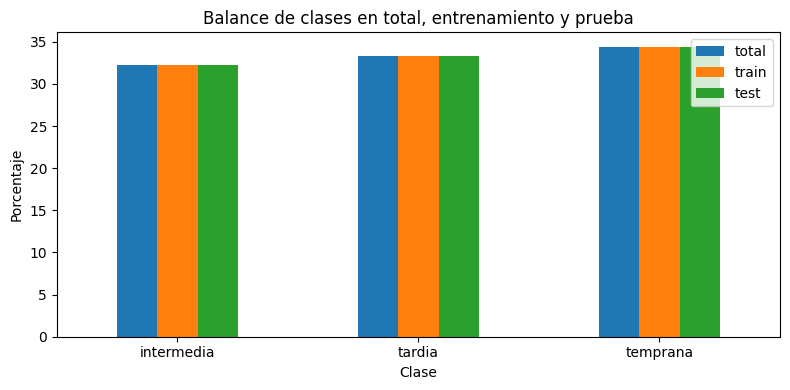

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Registros de entrenamiento: {len(X_train):,} ({len(X_train)/len(X)*100:.2f}%)")
print(f"Registros de prueba: {len(X_test):,} ({len(X_test)/len(X)*100:.2f}%)")

balance_total = y.value_counts(normalize=True).sort_index().rename("total")
balance_train = y_train.value_counts(normalize=True).sort_index().rename("train")
balance_test = y_test.value_counts(normalize=True).sort_index().rename("test")

balance = pd.concat([balance_total, balance_train, balance_test], axis=1) * 100
balance = balance.round(2)

display(balance)

balance.plot(kind="bar", figsize=(8, 4))
plt.title("Balance de clases en total, entrenamiento y prueba")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/grafico2_balance_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Preprocesamiento



In [19]:
def crear_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", crear_onehot())
])

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

## 8. Entrenamiento de varios modelos


In [20]:
parametros_modelos = [
    {
        "nombre": "RF_1_simple",
        "n_estimators": 120,
        "max_depth": 8,
        "min_samples_leaf": 30,
        "max_features": "sqrt"
    },
    {
        "nombre": "RF_2_intermedio",
        "n_estimators": 180,
        "max_depth": 15,
        "min_samples_leaf": 15,
        "max_features": "sqrt"
    },
    {
        "nombre": "RF_3_mas_flexible",
        "n_estimators": 220,
        "max_depth": None,
        "min_samples_leaf": 8,
        "max_features": "sqrt"
    }
]

modelos_entrenados = {}
resultados = []

for params in parametros_modelos:
    nombre = params["nombre"]
    print(f"Entrenando {nombre}...")

    rf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    modelo = Pipeline(steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", rf)
    ])

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)
    bal_acc_test = balanced_accuracy_score(y_test, pred_test)
    f1_macro_train = f1_score(y_train, pred_train, average="macro")
    f1_macro_test = f1_score(y_test, pred_test, average="macro")
    gap_f1 = f1_macro_train - f1_macro_test

    resultados.append({
        "modelo": nombre,
        "n_estimators": params["n_estimators"],
        "max_depth": str(params["max_depth"]),
        "min_samples_leaf": params["min_samples_leaf"],
        "max_features": params["max_features"],
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "balanced_accuracy_test": bal_acc_test,
        "f1_macro_train": f1_macro_train,
        "f1_macro_test": f1_macro_test,
        "gap_f1_train_test": gap_f1
    })

    modelos_entrenados[nombre] = modelo

resultados_df = pd.DataFrame(resultados).sort_values(
    by=["f1_macro_test", "gap_f1_train_test"],
    ascending=[False, True]
)

display(resultados_df)
resultados_df.to_csv("outputs/resumen_modelos.csv", index=False)

Entrenando RF_1_simple...
Entrenando RF_2_intermedio...
Entrenando RF_3_mas_flexible...


,modelo,n_estimators,max_depth,min_samples_leaf,max_features,accuracy_train,accuracy_test,balanced_accuracy_test,f1_macro_train,f1_macro_test,gap_f1_train_test
2,RF_3_mas_flexible,220,None,8,sqrt,0.5905,0.5147,0.5112,0.5816,0.5025,0.0792
1,RF_2_intermedio,180,15,15,sqrt,0.5362,0.5045,0.5004,0.5232,0.4895,0.0338
0,RF_1_simple,120,8,30,sqrt,0.5061,0.4977,0.4933,0.4897,0.4802,0.0095


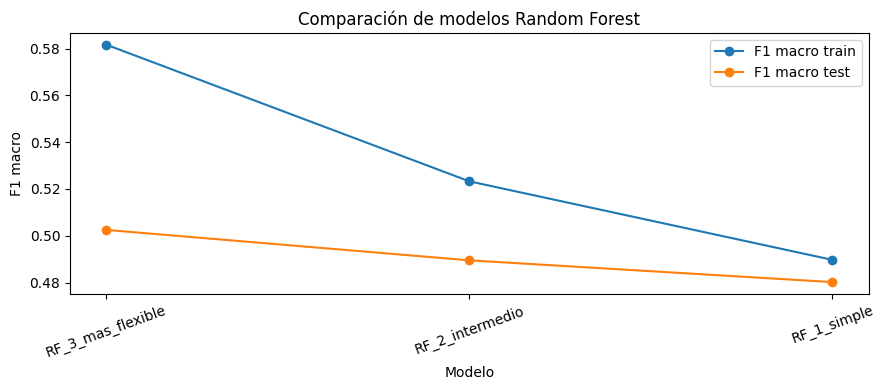

In [21]:
plt.figure(figsize=(9, 4))
plt.plot(resultados_df["modelo"], resultados_df["f1_macro_train"], marker="o", label="F1 macro train")
plt.plot(resultados_df["modelo"], resultados_df["f1_macro_test"], marker="o", label="F1 macro test")
plt.title("Comparación de modelos Random Forest")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/grafico3_comparacion_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Selección del modelo final


In [22]:

candidatos = resultados_df[resultados_df["gap_f1_train_test"] <= 0.10].copy()

if len(candidatos) > 0:
    mejor_fila = candidatos.sort_values(
        by=["f1_macro_test", "gap_f1_train_test"],
        ascending=[False, True]
    ).iloc[0]
else:
    mejor_fila = resultados_df.sort_values(
        by=["f1_macro_test", "gap_f1_train_test"],
        ascending=[False, True]
    ).iloc[0]

mejor_nombre = mejor_fila["modelo"]
modelo_final = modelos_entrenados[mejor_nombre]

print("Modelo final seleccionado:", mejor_nombre)
display(mejor_fila.to_frame("valor"))

y_pred = modelo_final.predict(X_test)

Modelo final seleccionado: RF_3_mas_flexible


,valor
modelo,RF_3_mas_flexible
n_estimators,220
max_depth,None
min_samples_leaf,8
max_features,sqrt
accuracy_train,0.5905
accuracy_test,0.5147
balanced_accuracy_test,0.5112
f1_macro_train,0.5816
f1_macro_test,0.5025


## 10. Resultados del modelo final


,Pred_temprana,Pred_intermedia,Pred_tardia
Real_temprana,2301,675,570
Real_intermedia,1118,1042,1167
Real_tardia,804,668,1963


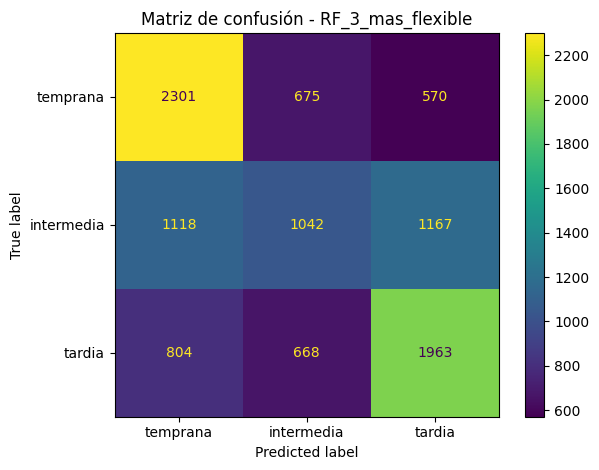

Reporte de clasificación:
              precision    recall  f1-score   support

    temprana       0.54      0.65      0.59      3546
  intermedia       0.44      0.31      0.36      3327
      tardia       0.53      0.57      0.55      3435

    accuracy                           0.51     10308
   macro avg       0.50      0.51      0.50     10308
weighted avg       0.51      0.51      0.50     10308



In [25]:
clases_validas = sorted(y_test.unique())
orden_clases = [c for c in ["temprana", "intermedia", "tardia"] if c in clases_validas]

mat_conf = confusion_matrix(y_test, y_pred, labels=orden_clases)

filas = [f"Real_{c}" for c in orden_clases]
cols  = [f"Pred_{c}" for c in orden_clases]
tabla_conf = pd.DataFrame(mat_conf, index=filas, columns=cols)

display(tabla_conf)
tabla_conf.to_csv("outputs/matriz_confusion_modelo_final.csv")

viz = ConfusionMatrixDisplay(confusion_matrix=mat_conf, display_labels=orden_clases)
viz.plot(values_format="d")
plt.title(f"Matriz de confusión - {mejor_nombre}")
plt.tight_layout()
plt.savefig("outputs/grafico4_matriz_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, labels=orden_clases))


## 11. Importancia de variables


,variable_original,importancia
8,ESCMUJ,0.1396
7,ESCHOM,0.1281
2,CIUOHOM,0.1118
3,CIUOMUJ,0.1013
19,PUEHOM,0.0649
20,PUEMUJ,0.0601
4,DEPOCU,0.0517
5,DEPREG,0.0489
1,AÑOREG,0.0466
13,MUPOCU,0.0459


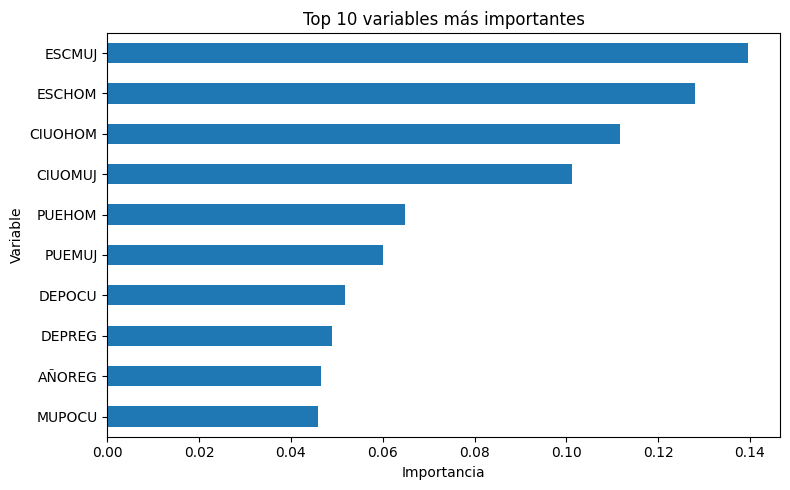

In [24]:
arbol_rf   = modelo_final.named_steps["modelo"]
pipeline_prep = modelo_final.named_steps["preprocesamiento"]

pesos = arbol_rf.feature_importances_

nombres_feat = []
vars_origen  = []

for col in num_cols:
    nombres_feat.append(col)
    vars_origen.append(col)

enc_ohe = pipeline_prep.named_transformers_["cat"].named_steps["onehot"]
for col, categorias in zip(cat_cols, enc_ohe.categories_):
    for cat in categorias:
        nombres_feat.append(f"{col}_{cat}")
        vars_origen.append(col)

n = min(len(pesos), len(nombres_feat), len(vars_origen))

df_pesos = pd.DataFrame({
    "feature":   nombres_feat[:n],
    "var_orig":  vars_origen[:n],
    "peso":      pesos[:n]
})

resumen_vars = (
    df_pesos
    .groupby("var_orig", as_index=False)["peso"]
    .sum()
    .sort_values("peso", ascending=False)
    .rename(columns={"var_orig": "variable_original", "peso": "importancia"})
)

display(resumen_vars.head(15))
resumen_vars.to_csv("outputs/importancia_variables_modelo_final.csv", index=False)

resumen_vars.head(10).sort_values("importancia").plot(
    kind="barh",
    x="variable_original",
    y="importancia",
    figsize=(8, 5),
    legend=False
)
plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("outputs/grafico5_importancia_variables.png", dpi=300, bbox_inches="tight")
plt.show()
